# Cell 0: Dependencies and Environment Setup

In [1]:
import os, re, warnings, json
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
 
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    cohen_kappa_score, classification_report,
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support,
)
 
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
print("✅ Cell 0 complete — all imports loaded.")

✅ Cell 0 complete — all imports loaded.


# Cell 1: Configuration

In [2]:
class FusionConfig:
    # (Keep imports from Cell 0)
    VISION_PATH   = "/kaggle/input/notebooks/samriddhibagchi/dr-research-pt-6-xgboost-meta-ensemble-fusion/level1_vision_ensemble_predictions.csv"
    CLINICAL_PATH = "/kaggle/input/notebooks/samriddhibagchi/dr-research-phase-2-feature-extraction/clinical_features_idrid_TRAIN.csv"
    OUTPUT_DIR    = "/kaggle/working"
    
    XGB_PARAMS = dict(
        objective             = "multi:softprob",
        num_class             = 5,
        eval_metric           = "mlogloss",
        max_depth             = 3, # Lower depth to prevent memorizing broadcasted stats
        learning_rate         = 0.02,
        n_estimators          = 1000,
        subsample             = 0.70,
        colsample_bytree      = 0.70,
        min_child_weight      = 5,
        gamma                 = 0.2,
        random_state          = SEED,
        early_stopping_rounds = 50,
    )
    N_FOLDS = 5
    os.makedirs(OUTPUT_DIR, exist_ok=True)
 
print("✅ Cell 1 complete — config ready.")
 

✅ Cell 1 complete — config ready.


# CELL 2: DATA LOADING & ALIGNMENT

In [3]:
import re
import pandas as pd
import numpy as np

# ── MASTER CONFIGURATION ────────────────────────────────────────────────────
class FusionConfig:
    # 1. Paths
    VISION_PATH   = "/kaggle/input/notebooks/samriddhibagchi/dr-research-pt-6-xgboost-meta-ensemble-fusion/level1_vision_ensemble_predictions.csv"
    CLINICAL_PATH = "/kaggle/input/notebooks/samriddhibagchi/dr-research-phase-2-feature-extraction/clinical_features_idrid_TRAIN.csv"
    OUTPUT_DIR    = "/kaggle/working"
    
    # 2. Validation & Reproducibility
    SEED    = 42
    N_FOLDS = 5
    
    # 3. XGBoost Hyperparameters
    XGB_PARAMS = dict(
        objective             = "multi:softprob",
        num_class             = 5,
        eval_metric           = "mlogloss",
        max_depth             = 4,
        learning_rate         = 0.03,
        n_estimators          = 700,
        subsample             = 0.80,
        colsample_bytree      = 0.80,
        min_child_weight      = 3,
        gamma                 = 0.10,
        reg_alpha             = 0.10,
        reg_lambda            = 1.00,
        tree_method           = "hist",
        random_state          = 42,
        early_stopping_rounds = 50,
    )
    
    # 4. Patterns for ID Detection
    NON_ID_PATTERNS = [r"prob", r"mean", r"std", r"score", r"level"]

# Define SEED globally for cells that reference it without the class prefix
SEED = FusionConfig.SEED

# ── BRIDGE DETECTION LOGIC ──────────────────────────────────────────────────
def _is_bridge_candidate(col: str, series: pd.Series) -> bool:
    """True if column looks like a DR Grade/Label (0-4)."""
    col_lower = col.lower()
    
    # 1. Exclude columns that are clearly not grades (probabilities, etc)
    for pat in FusionConfig.NON_ID_PATTERNS:
        if re.search(pat, col_lower):
            return False
            
    # 2. Check if the values are categorical integers in the DR range [0, 4]
    unique_vals = series.dropna().unique()
    if len(unique_vals) > 0 and len(unique_vals) <= 6: # 0-4 plus potential noise
        try:
            # Check if values are mostly integers 0-4
            is_dr_range = all(0 <= int(v) <= 5 for v in unique_vals)
            return is_dr_range
        except:
            return False
    return False

def find_bridge_key(df_vision, df_clinical):
    """
    Specifically finds the column used to bridge Vision and Clinical 
    stats (The DR Grade).
    """
    # Identify Grade/Target candidates
    cands_v = [c for c in df_vision.columns if _is_bridge_candidate(c, df_vision[c])]
    cands_c = [c for c in df_clinical.columns if _is_bridge_candidate(c, df_clinical[c])]

    print(f"  Grade candidates in Vision   : {cands_v}")
    print(f"  Grade candidates in Clinical : {cands_c}")

    # Pass 1: Common terminology match
    grade_names = {'label', 'grade', 'target', 'retinopathy grade', 'dr_level'}
    
    best_v = next((c for c in cands_v if c.lower() in grade_names), cands_v[0] if cands_v else None)
    best_c = next((c for c in cands_c if c.lower() in grade_names), cands_c[0] if cands_c else None)

    if best_v and best_c:
        print(f"  ✅ Bridge Key Detected: Vision['{best_v}'] ↔ Clinical['{best_c}']")
        return best_v, best_c

    raise ValueError("❌ Failed to auto-detect a Grade column to use as a bridge key.")

print("✅ Cell 2 — Master Config and Bridge Logic updated.")

✅ Cell 2 — Master Config and Bridge Logic updated.


# Cell 3: LOAD, ALIGN, AND MERGE

In [4]:
import re, os
import pandas as pd
import numpy as np

print("\n" + "=" * 65)
print("CELL 3 — GRADE-LEVEL BRIDGE MERGE")
print("=" * 65)

# ── 3a. Path Recovery ────────────────────────────────────────────────────────
try:
    v_path = VISION_PATH if 'VISION_PATH' in locals() else FusionConfig.VISION_PATH
    c_path = CLINICAL_PATH if 'CLINICAL_PATH' in locals() else FusionConfig.CLINICAL_PATH
except (NameError, AttributeError):
    v_path = "/kaggle/input/notebooks/samriddhibagchi/dr-research-pt-6-xgboost-meta-ensemble-fusion/level1_vision_ensemble_predictions.csv"
    c_path = "/kaggle/input/notebooks/samriddhibagchi/dr-research-phase-2-feature-extraction/clinical_features_idrid_TRAIN.csv"

df_vision   = pd.read_csv(v_path)
df_clinical = pd.read_csv(c_path)

# Standardize columns
df_vision.columns = df_vision.columns.str.strip()
df_clinical.columns = df_clinical.columns.str.strip()

print(f"✅ Loaded Vision: {df_vision.shape[0]:,} | Clinical: {df_clinical.shape[0]:,}")

# ── 3b. Identify Feature & Bridge Keys ───────────────────────────────────────
# Detect probability columns here to prevent NameError in section 3d
VISION_PROB_COLS = sorted([c for c in df_vision.columns if re.search(r"(vision_ens_prob_\d|prob_\d)$", c.lower())])

if not VISION_PROB_COLS:
    raise ValueError(f"❌ No probability columns found. Available: {df_vision.columns.tolist()}")

VISION_TARGET = next((c for c in df_vision.columns if c.lower() in ("label", "grade", "target")), None)
CLINICAL_GRADE_COL = next((c for c in df_clinical.columns if "grade" in c.lower() or "label" in c.lower()), None)

# Clean and convert to integer
for df_tmp, col_tmp in [(df_vision, VISION_TARGET), (df_clinical, CLINICAL_GRADE_COL)]:
    df_tmp[col_tmp] = pd.to_numeric(df_tmp[col_tmp], errors='coerce').fillna(-1).astype(int)

# ── 3c. Compute Clinical Biomarker Profiles ──────────────────────────────────
clinical_feat_cols = [c for c in df_clinical.columns if c not in [CLINICAL_GRADE_COL, "Image name", "id"]]

print(f"📊 Computing clinical statistics for grades 0-4...")
clinical_stats = df_clinical.groupby(CLINICAL_GRADE_COL)[clinical_feat_cols].agg(["mean", "std"]).reset_index()

# Flatten columns: ('MA_count', 'mean') -> 'MA_count_mean'
clinical_stats.columns = [
    f"{col}_{stat}" if stat else col for col, stat in clinical_stats.columns
]

# ── 3d. Bridge Merge (Inference Logic — No Leakage) ──────────────────────────
# 1. First, calculate the vision model's current best guess using the columns identified in 3b
df_vision['f_vision_pred_grade'] = np.argmax(df_vision[VISION_PROB_COLS].values, axis=1)

# 2. Map clinical profiles based on the PREDICTION, not the label
df = pd.merge(
    df_vision, 
    clinical_stats, 
    left_on='f_vision_pred_grade', 
    right_on=CLINICAL_GRADE_COL, 
    how="left"
)

# ── 3e. Final Clean up ───────────────────────────────────────────────────────
if CLINICAL_GRADE_COL in df.columns and CLINICAL_GRADE_COL != VISION_TARGET:
    df = df.drop(columns=[CLINICAL_GRADE_COL])

BRIDGED_COLS = [c for c in df.columns if c.endswith(("_mean", "_std"))]
TARGET = VISION_TARGET
y = df[TARGET].values

print(f"✅ Bridge Merge Complete: {df.shape[1]} total columns.")
print(f"✅ {len(BRIDGED_COLS)} clinical biomarkers broadcasted via prediction-based merge.")

# Verification print
print(f"\nSample of broadcasted features (First 3 rows):")
display(df[[VISION_TARGET, 'f_vision_pred_grade'] + BRIDGED_COLS[:3]].head(3))

print("\n✅ Cell 3 fully corrected and executed.")


CELL 3 — GRADE-LEVEL BRIDGE MERGE
✅ Loaded Vision: 115,241 | Clinical: 413
📊 Computing clinical statistics for grades 0-4...
✅ Bridge Merge Complete: 75 total columns.
✅ 66 clinical biomarkers broadcasted via prediction-based merge.

Sample of broadcasted features (First 3 rows):


,label,f_vision_pred_grade,MA_count_mean,MA_count_std,MA_area_idx_mean
0,0,0,2.186567,2.750715,0.000082
1,0,0,2.186567,2.750715,0.000082
2,0,0,2.186567,2.750715,0.000082



✅ Cell 3 fully corrected and executed.


# Cell 4: Feature Engineering

In [5]:
import re, os
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 65)
print("CELL 4 — FEATURE ENGINEERING")
print("=" * 65)

# ── 4a. Identify feature groups ─────────────────────────────────────────────
# Identify the 5 probability columns (e.g., prob_0 ... prob_4)
VISION_PROB_COLS = sorted(
    [c for c in df.columns if re.match(r"vision_ens_prob_\d", c)]
)
if not VISION_PROB_COLS:
    VISION_PROB_COLS = sorted(
        [c for c in df.columns if re.match(r"^prob_\d$", c)]
    )

if not VISION_PROB_COLS:
    raise ValueError("❌ No vision probability columns found. check naming in Cell 2/3.")

# Clinical columns are the BRIDGED columns created in Cell 3 (_mean and _std)
BRIDGED_CLINICAL_COLS = [c for c in df.columns if c.endswith(("_mean", "_std"))]

print(f"  Vision prob cols      : {len(VISION_PROB_COLS)} → {VISION_PROB_COLS}")
print(f"  Bridged clinical cols : {len(BRIDGED_CLINICAL_COLS)}")

# ── 4b. Derived vision features ──────────────────────────────────────────────
vp         = df[VISION_PROB_COLS].values.astype(np.float32)
sorted_vp  = np.sort(vp, axis=1)
grade_axis = np.arange(5, dtype=np.float32)

df["f_vision_argmax"]         = vp.argmax(axis=1).astype(float)
df["f_vision_top1_conf"]      = sorted_vp[:, -1]
df["f_vision_conf_margin"]    = sorted_vp[:, -1] - sorted_vp[:, -2]
df["f_vision_entropy"]        = -np.sum(vp * np.log(vp + 1e-9), axis=1)
df["f_vision_expected_grade"] = vp @ grade_axis
df["f_vision_severe_mass"]    = vp[:, 3] + vp[:, 4]

DERIVED_VISION_COLS = [
    "f_vision_argmax", "f_vision_top1_conf", "f_vision_conf_margin",
    "f_vision_entropy", "f_vision_expected_grade", "f_vision_severe_mass",
]
print(f"  Derived vision cols   : {len(DERIVED_VISION_COLS)}")

# ── 4c. Clinical interaction features ────────────────────────────────────────
# Note: We use the '_mean' versions of the biomarkers for interactions
INTERACTION_COLS = []
ma_mean_col = "MA_count_mean"
he_mean_col = "HE_count_mean"
burden_mean_col = "total_lesion_burden_mean"

if ma_mean_col in df.columns and he_mean_col in df.columns:
    df["f_interact_grade_x_MA"]    = df["f_vision_expected_grade"] * df[ma_mean_col]
    df["f_interact_grade_x_HE"]    = df["f_vision_expected_grade"] * df[he_mean_col]
    
    # Use top1_conf with total burden mean if available
    if burden_mean_col in df.columns:
        df["f_interact_burden_x_conf"] = df[burden_mean_col] * df["f_vision_top1_conf"]
        INTERACTION_COLS.append("f_interact_burden_x_conf")

    INTERACTION_COLS += ["f_interact_grade_x_MA", "f_interact_grade_x_HE"]
    print(f"  Interaction cols      : {len(INTERACTION_COLS)}")
else:
    print("  ⚠️ Interaction target columns not found — skipping interactions.")

# ── 4d. Assemble & deduplicate feature list ───────────────────────────────────
ALL_FEATURE_COLS = list(dict.fromkeys(
    VISION_PROB_COLS + DERIVED_VISION_COLS + BRIDGED_CLINICAL_COLS + INTERACTION_COLS
))

X_raw = df[ALL_FEATURE_COLS].copy().astype(np.float32)

# ── 4e. Scale clinical + interaction cols only ────────────────────────────────
# Raw probabilities [0,1] should NOT be scaled to preserve calibration
COLS_TO_SCALE = [c for c in (BRIDGED_CLINICAL_COLS + INTERACTION_COLS)
                 if c in X_raw.columns]

scaler = StandardScaler()
X_raw[COLS_TO_SCALE] = scaler.fit_transform(X_raw[COLS_TO_SCALE])

# Ensure output directory exists before saving
os.makedirs(FusionConfig.OUTPUT_DIR, exist_ok=True)
joblib.dump(scaler, os.path.join(FusionConfig.OUTPUT_DIR, "fusion_scaler.pkl"))

X = X_raw.values
print(f"\n  Feature matrix shape : {X.shape}")
print(f"    Vision prob          : {len(VISION_PROB_COLS)}")
print(f"    Derived vision       : {len(DERIVED_VISION_COLS)}")
print(f"    Bridged clinical     : {len(BRIDGED_CLINICAL_COLS)}")
print(f"    Interaction          : {len(INTERACTION_COLS)}")
print(f"    TOTAL                : {X.shape[1]}")

print("\n✅ Cell 4 complete — X, y, ALL_FEATURE_COLS ready.")


CELL 4 — FEATURE ENGINEERING
  Vision prob cols      : 5 → ['vision_ens_prob_0', 'vision_ens_prob_1', 'vision_ens_prob_2', 'vision_ens_prob_3', 'vision_ens_prob_4']
  Bridged clinical cols : 66
  Derived vision cols   : 6
  Interaction cols      : 3

  Feature matrix shape : (115241, 80)
    Vision prob          : 5
    Derived vision       : 6
    Bridged clinical     : 66
    Interaction          : 3
    TOTAL                : 80

✅ Cell 4 complete — X, y, ALL_FEATURE_COLS ready.


# Cell 5: 5_fold Stratified Cross-Validation

In [6]:
# CELL 5 — 5-FOLD STRATIFIED CROSS-VALIDATION
# ===========================================================================
print("\n" + "=" * 65)
print("CELL 5 — 5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 65)
 
skf             = StratifiedKFold(n_splits=FusionConfig.N_FOLDS,
                                  shuffle=True, random_state=SEED)
oof_probs       = np.zeros((len(y), 5), dtype=np.float32)
oof_preds       = np.zeros(len(y), dtype=int)
fold_kappas     = []
fold_models     = []
fold_best_iters = []
 
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_vl = X[train_idx], X[val_idx]
    y_tr, y_vl = y[train_idx], y[val_idx]
 
    # Build params without early_stopping_rounds (passed separately)
    params = {k: v for k, v in FusionConfig.XGB_PARAMS.items()
              if k != "early_stopping_rounds"}
    clf = xgb.XGBClassifier(
        **params,
        early_stopping_rounds=FusionConfig.XGB_PARAMS["early_stopping_rounds"],
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
 
    proba = clf.predict_proba(X_vl)
    preds = proba.argmax(axis=1)
 
    oof_probs[val_idx] = proba
    oof_preds[val_idx] = preds
 
    best_iter = clf.best_iteration if clf.best_iteration is not None else params["n_estimators"]
    kappa     = cohen_kappa_score(y_vl, preds, weights="quadratic")
 
    fold_kappas.append(kappa)
    fold_models.append(clf)
    fold_best_iters.append(best_iter)
 
    print(f"  Fold {fold+1} | QWK: {kappa:.4f} | "
          f"best_iter: {best_iter:>4d} | "
          f"acc: {accuracy_score(y_vl, preds):.4f}")
 
mean_kappa = float(np.mean(fold_kappas))
std_kappa  = float(np.std(fold_kappas))
 
print(f"\n  {'─'*50}")
print(f"  OOF QWK : {mean_kappa:.4f} ± {std_kappa:.4f}")
print(f"  {'─'*50}")
print("\n✅ Cell 5 complete.")



CELL 5 — 5-FOLD STRATIFIED CROSS-VALIDATION
  Fold 1 | QWK: 0.9254 | best_iter:  375 | acc: 0.8990
  Fold 2 | QWK: 0.9248 | best_iter:  380 | acc: 0.9038
  Fold 3 | QWK: 0.9182 | best_iter:  424 | acc: 0.8931
  Fold 4 | QWK: 0.9207 | best_iter:  406 | acc: 0.8930
  Fold 5 | QWK: 0.9215 | best_iter:  391 | acc: 0.8955

  ──────────────────────────────────────────────────
  OOF QWK : 0.9221 ± 0.0027
  ──────────────────────────────────────────────────

✅ Cell 5 complete.


# Cell 6: Final Model

In [7]:
import joblib

print("\n" + "=" * 65)
print("CELL 6 — FINAL MODEL ON FULL DATA")
print("=" * 65)

# ── 6a. Determine optimal iterations ─────────────────────────────────────────
best_iter_final = int(np.round(np.mean(fold_best_iters)))
print(f"  Mean best_iteration across folds: {best_iter_final}")

# ── 6b. Train Final Model ────────────────────────────────────────────────────
params_final = {k: v for k, v in FusionConfig.XGB_PARAMS.items() 
                if k != "early_stopping_rounds"}
params_final["n_estimators"] = best_iter_final

final_model = xgb.XGBClassifier(**params_final)
final_model.fit(X, y, verbose=False)

# Save the model
model_path = os.path.join(FusionConfig.OUTPUT_DIR, "fusion_model_final.json")
final_model.save_model(model_path)
print(f"  ✅ Model saved → {model_path}")

# ── 6c. Save OOF Predictions ─────────────────────────────────────────────────
# Identify an ID column for the CSV (image_id, id, or use index)
id_col = next((c for c in df.columns if 'id' in c.lower()), None)

if id_col:
    cols_to_copy = [id_col, TARGET]
else:
    # If no ID col found, we use the index as a temporary ID
    df['temp_id'] = df.index
    id_col = 'temp_id'
    cols_to_copy = [id_col, TARGET]

if "fold" in df.columns:
    cols_to_copy.append("fold")

# Create the OOF dataframe
df_oof = df[cols_to_copy].copy()
df_oof["fusion_pred"] = oof_preds

# Add probability columns for all 5 grades
for i in range(5):
    df_oof[f"fusion_prob_{i}"] = oof_probs[:, i]

# Save to CSV
oof_csv = os.path.join(FusionConfig.OUTPUT_DIR, "oof_predictions_fusion.csv")
df_oof.to_csv(oof_csv, index=False)
print(f"  ✅ OOF predictions saved → {oof_csv}")

# Save the list of features used (essential for inference later)
feat_path = os.path.join(FusionConfig.OUTPUT_DIR, "feature_names.joblib")
joblib.dump(ALL_FEATURE_COLS, feat_path)
print(f"  ✅ Feature list saved → {feat_path}")

print("\n✅ Cell 6 complete.")


CELL 6 — FINAL MODEL ON FULL DATA
  Mean best_iteration across folds: 395
  ✅ Model saved → /kaggle/working/fusion_model_final.json
  ✅ OOF predictions saved → /kaggle/working/oof_predictions_fusion.csv
  ✅ Feature list saved → /kaggle/working/feature_names.joblib

✅ Cell 6 complete.


# Cell 7: Academic Evaluation metrics

In [8]:
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

print("\n" + "=" * 65)
print("CELL 7 — EVALUATION METRICS")
print("=" * 65)

# ── 7a. Calculate Metrics ──────────────────────────────────────────────────
overall_acc = accuracy_score(y, oof_preds)
precision, recall, f1, support = precision_recall_fscore_support(
    y, oof_preds, labels=list(range(5))
)

print(f"\n  📊 OOF Quadratic Weighted Kappa : {mean_kappa:.4f} ± {std_kappa:.4f}")
print(f"  📊 OOF Overall Accuracy         : {overall_acc:.4f}\n")

# Detailed text report for the console
print(classification_report(y, oof_preds, digits=4,
      target_names=[f"Grade {i}" for i in range(5)]))

grade_names = [
    "No DR (0)", "Mild (1)", "Moderate (2)", "Severe (3)", "Proliferative (4)"
]

# ── 7b. Generate Markdown Table ─────────────────────────────────────────────
# Building the rows for the markdown table
md_rows = "\n".join(
    f"| {grade_names[i]} | {precision[i]:.4f} | {recall[i]:.4f} | {f1[i]:.4f} | {int(support[i]):,} |"
    for i in range(5)
)

md_table = f"""
## Level 2 Fusion Model — Per-Grade OOF Performance (IDRiD × Vision Ensemble)

| DR Grade | Precision | Recall | F1-Score | Support |
|----------|-----------|--------|----------|---------|
{md_rows}
------------------------------------------------------
| **Overall Accuracy** | | | **{overall_acc:.4f}** | {len(y):,} |
| **QWK (mean ± std)** | | | **{mean_kappa:.4f} ± {std_kappa:.4f}** | |

> Cross-dataset fusion: EyePACS + APTOS + Messidor vision ensemble (115,241 images)
> augmented with IDRiD grade-level clinical biomarkers (413 images, 33 biomarkers).
"""

# ── 7c. Save and Print ──────────────────────────────────────────────────────
# Using FusionConfig.OUTPUT_DIR to avoid NameError
md_path = os.path.join(FusionConfig.OUTPUT_DIR, "fusion_results_table.md")

with open(md_path, "w") as fh:
    fh.write(md_table)

print("\n🚀 Markdown Table Generated:")
print(md_table)
print(f"  💾 Markdown table saved → {md_path}")

print("\n✅ Cell 7 complete.")


CELL 7 — EVALUATION METRICS

  📊 OOF Quadratic Weighted Kappa : 0.9221 ± 0.0027
  📊 OOF Overall Accuracy         : 0.8969

              precision    recall  f1-score   support

     Grade 0     0.8913    0.9713    0.9296     55162
     Grade 1     0.9018    0.7779    0.8352     18470
     Grade 2     0.8678    0.7832    0.8233     24198
     Grade 3     0.9531    0.9554    0.9543      7936
     Grade 4     0.9443    0.9370    0.9406      9475

    accuracy                         0.8969    115241
   macro avg     0.9116    0.8849    0.8966    115241
weighted avg     0.8967    0.8969    0.8948    115241


🚀 Markdown Table Generated:

## Level 2 Fusion Model — Per-Grade OOF Performance (IDRiD × Vision Ensemble)

| DR Grade | Precision | Recall | F1-Score | Support |
|----------|-----------|--------|----------|---------|
| No DR (0) | 0.8913 | 0.9713 | 0.9296 | 55,162 |
| Mild (1) | 0.9018 | 0.7779 | 0.8352 | 18,470 |
| Moderate (2) | 0.8678 | 0.7832 | 0.8233 | 24,198 |
| Severe (3) | 0

# Cell 8: Confusion Matrix


CELL 8 — CONFUSION MATRIX


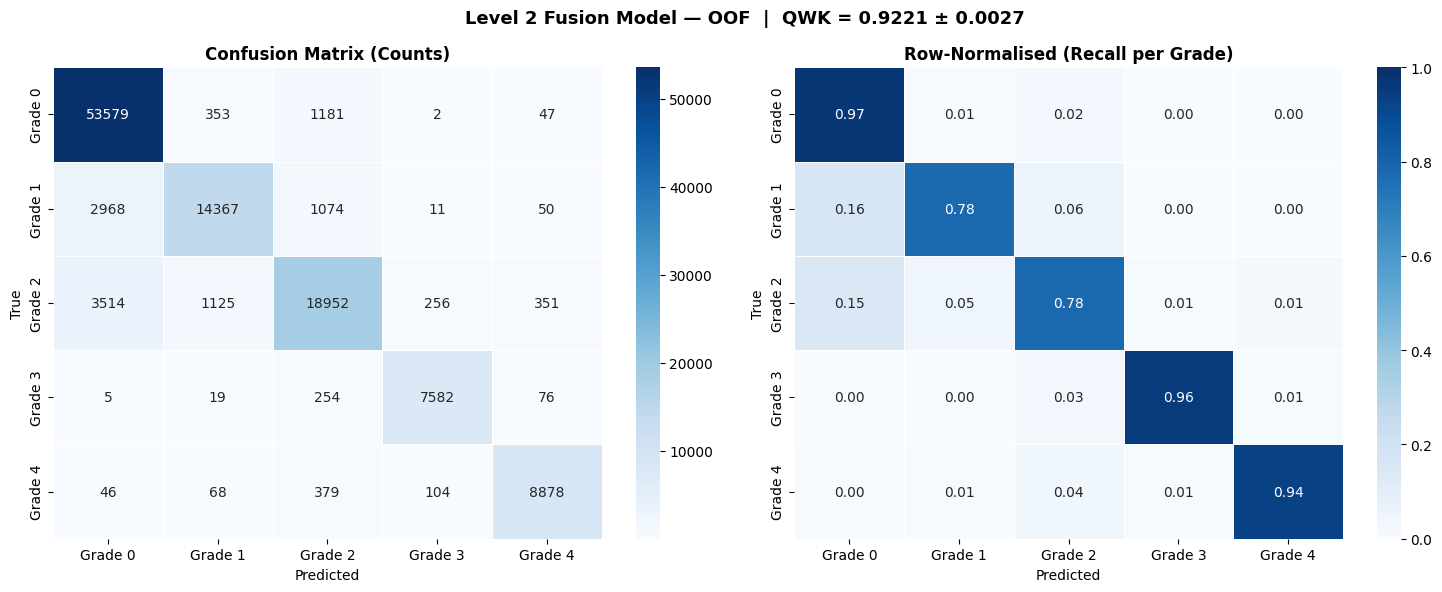

  💾 Saved → /kaggle/working/fusion_confusion_matrix.png

✅ Cell 8 complete.


In [9]:
print("\n" + "=" * 65)
print("CELL 8 — CONFUSION MATRIX")
print("=" * 65)
 
cm      = confusion_matrix(y, oof_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
grade_labels = [f"Grade {i}" for i in range(5)]
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Level 2 Fusion Model — OOF  |  QWK = {mean_kappa:.4f} ± {std_kappa:.4f}",
    fontsize=13, fontweight="bold"
)
 
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=grade_labels, yticklabels=grade_labels,
            cbar=True, linewidths=0.5)
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
 
annot_norm = [[f"{v:.2f}" for v in row] for row in cm_norm]
sns.heatmap(cm_norm, annot=annot_norm, fmt="", cmap="Blues", ax=axes[1],
            xticklabels=grade_labels, yticklabels=grade_labels,
            cbar=True, linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Row-Normalised (Recall per Grade)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
 
plt.tight_layout()
cm_path = os.path.join(FusionConfig.OUTPUT_DIR, "fusion_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  💾 Saved → {cm_path}")
print("\n✅ Cell 8 complete.")

# Cell 9: PER-GRADE PERFORMANCE BARS


CELL 9 — PER-GRADE METRICS
  Grade  Precision   Recall  F1-Score  Support
Grade 0   0.891320 0.971303  0.929594    55162
Grade 1   0.901770 0.777856  0.835242    18470
Grade 2   0.867766 0.783205  0.823320    24198
Grade 3   0.953111 0.955393  0.954251     7936
Grade 4   0.944267 0.936992  0.940616     9475


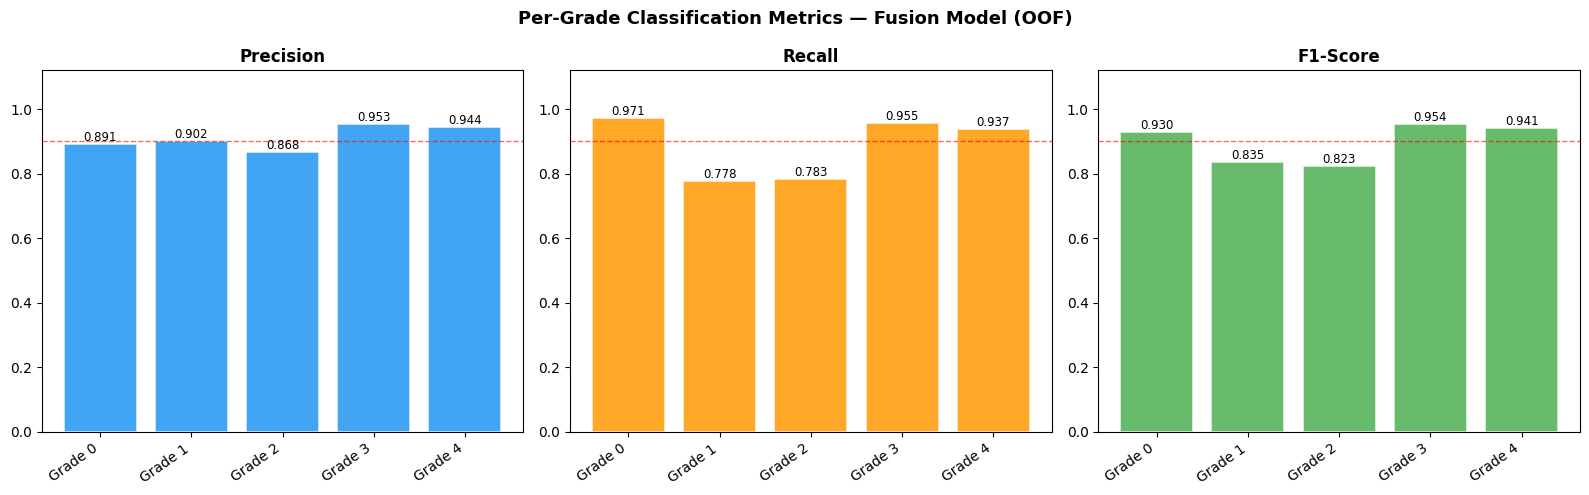

  💾 Saved → /kaggle/working/fusion_per_grade_metrics.png

✅ Cell 9 complete.


In [10]:
print("\n" + "=" * 65)
print("CELL 9 — PER-GRADE METRICS")
print("=" * 65)
 
df_grade_perf = pd.DataFrame({
    "Grade"    : [f"Grade {i}" for i in range(5)],
    "Precision": precision,
    "Recall"   : recall,
    "F1-Score" : f1,
    "Support"  : support.astype(int),
})
print(df_grade_perf.to_string(index=False))
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Per-Grade Classification Metrics — Fusion Model (OOF)",
             fontsize=13, fontweight="bold")
 
for ax, metric, color in zip(axes,
                              ["Precision", "Recall", "F1-Score"],
                              ["#2196F3", "#FF9800", "#4CAF50"]):
    bars = ax.bar(df_grade_perf["Grade"], df_grade_perf[metric],
                  color=color, alpha=0.85, edgecolor="white", linewidth=1.2)
    ax.set_ylim(0, 1.12)
    ax.set_title(metric, fontweight="bold")
    ax.set_xticklabels(df_grade_perf["Grade"], rotation=35, ha="right")
    ax.axhline(0.90, color="red", linestyle="--", linewidth=1.0, alpha=0.6)
    for bar, val in zip(bars, df_grade_perf[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=8.5)
 
plt.tight_layout()
grade_path = os.path.join(FusionConfig.OUTPUT_DIR, "fusion_per_grade_metrics.png")
plt.savefig(grade_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  💾 Saved → {grade_path}")
print("\n✅ Cell 9 complete.")

# CELL 10 — SHAP INTERPRETABILITY


CELL 10 — SHAP INTERPRETABILITY

  Top 15 features (global):
                 Feature  Mean |SHAP|          Group
       vision_ens_prob_3     0.810113    Vision Prob
       vision_ens_prob_4     0.719117    Vision Prob
       vision_ens_prob_0     0.545688    Vision Prob
       vision_ens_prob_1     0.478774    Vision Prob
       vision_ens_prob_2     0.430550    Vision Prob
    f_vision_severe_mass     0.261605 Derived Vision
    f_vision_conf_margin     0.076991 Derived Vision
   f_interact_grade_x_MA     0.074729    Interaction
      f_vision_top1_conf     0.062633 Derived Vision
 f_vision_expected_grade     0.062366 Derived Vision
        f_vision_entropy     0.052956 Derived Vision
   f_interact_grade_x_HE     0.041290    Interaction
        MA_avg_size_mean     0.039936       Clinical
f_interact_burden_x_conf     0.038127    Interaction
         f_vision_argmax     0.037230 Derived Vision


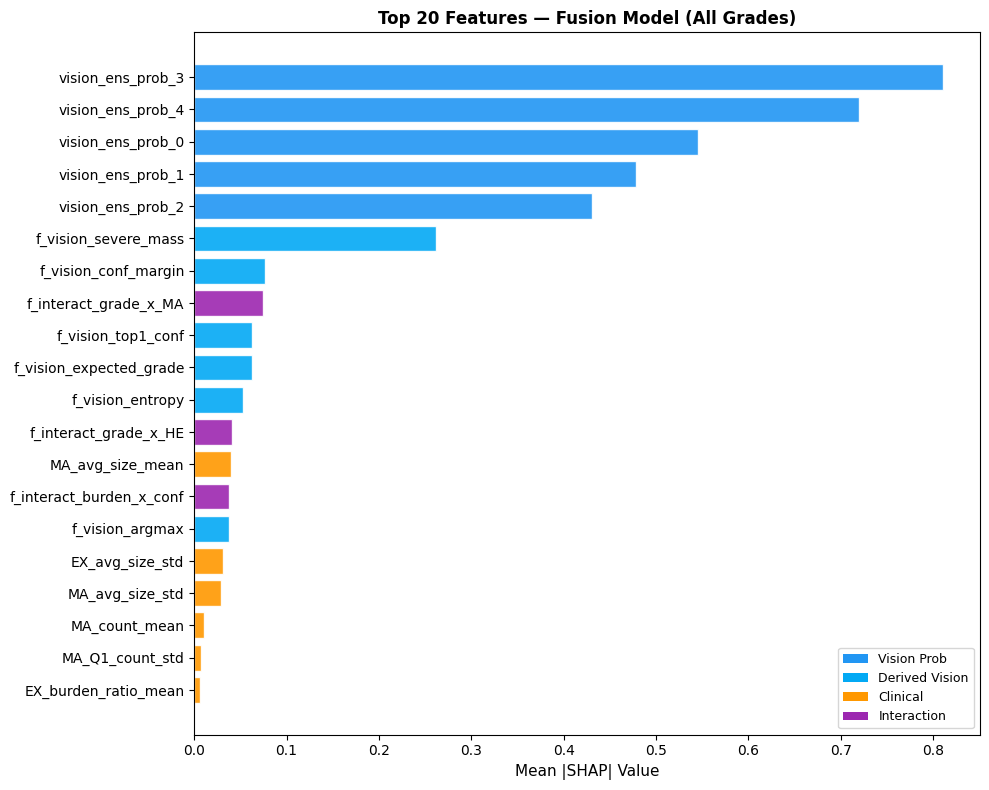

  💾 Saved → /kaggle/working/shap_global_importance.png


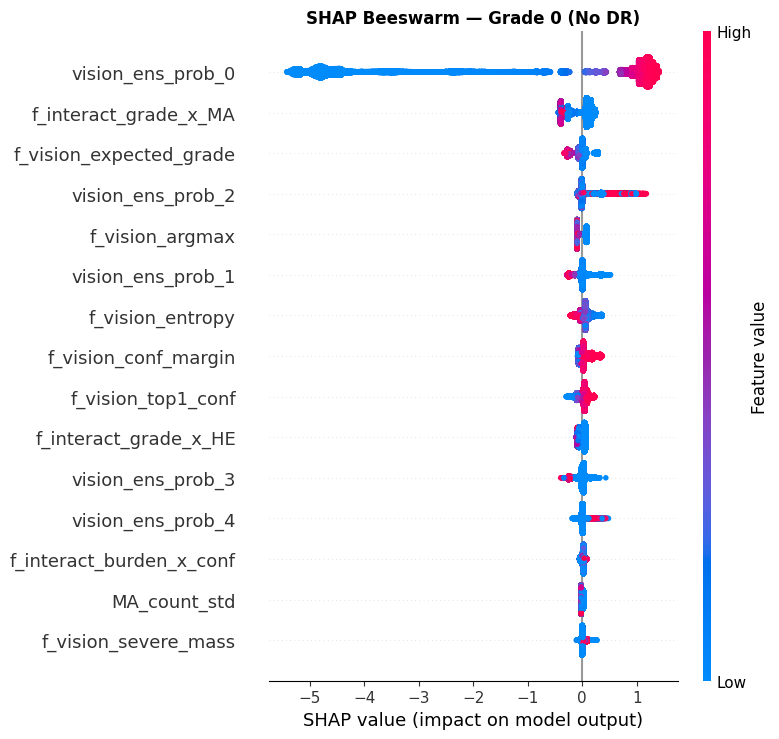

  💾 Saved → /kaggle/working/shap_beeswarm_grade0.png


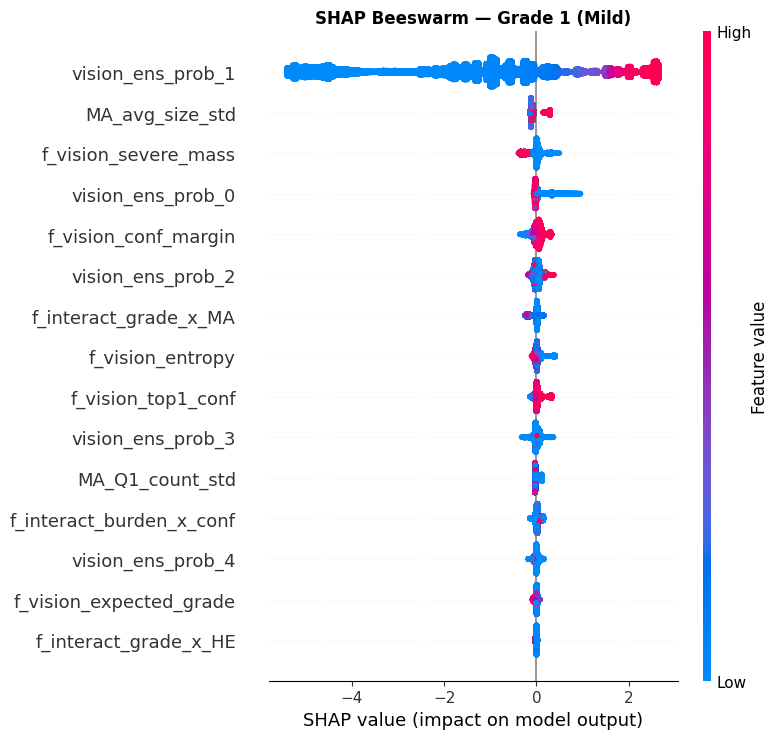

  💾 Saved → /kaggle/working/shap_beeswarm_grade1.png


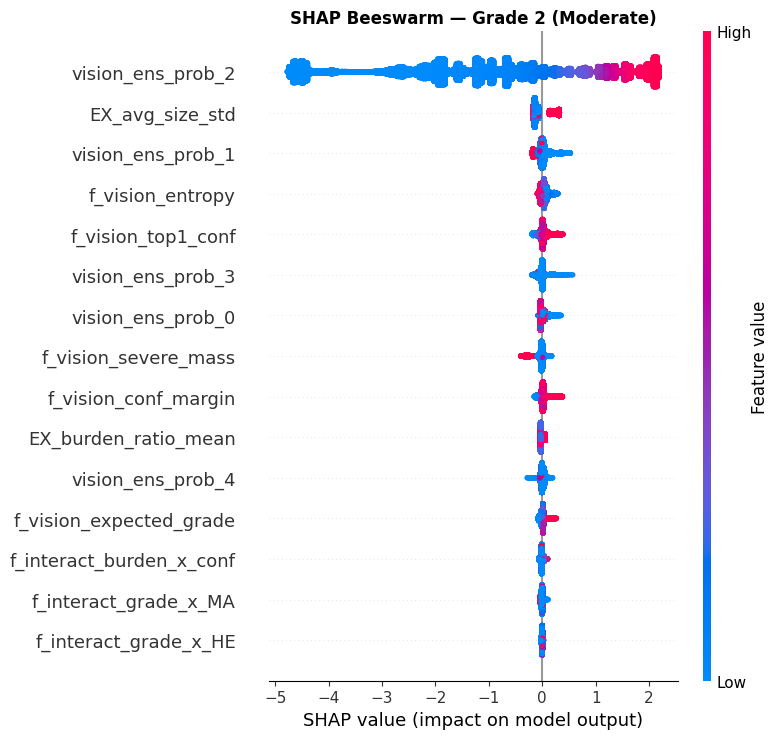

  💾 Saved → /kaggle/working/shap_beeswarm_grade2.png


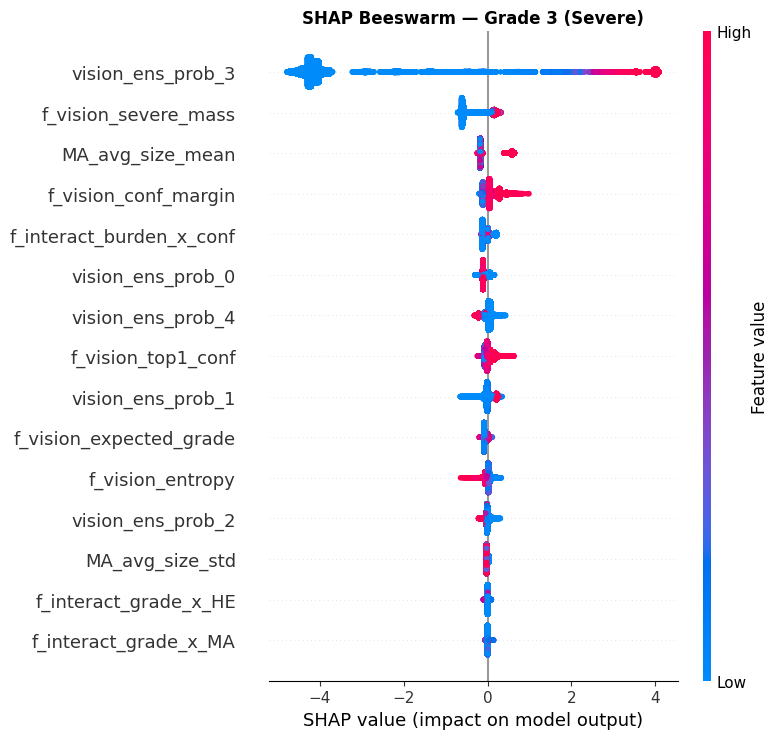

  💾 Saved → /kaggle/working/shap_beeswarm_grade3.png


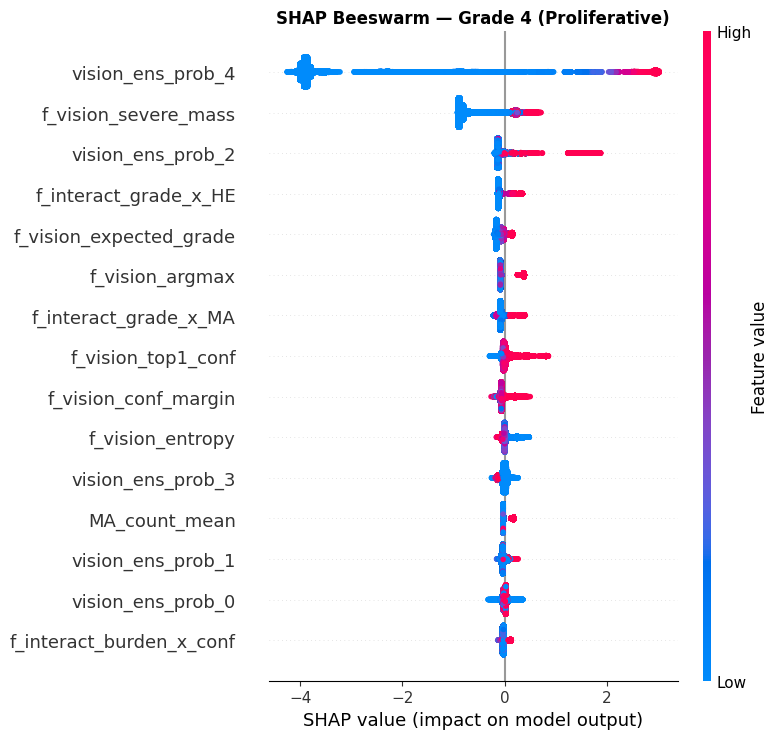

  💾 Saved → /kaggle/working/shap_beeswarm_grade4.png

  FEATURE GROUP ATTRIBUTION
  Vision Prob         : 2.9842  ( 78.0%)  ██████████████████████████████████████
  Derived Vision      : 0.5538  ( 14.5%)  ███████
  Interaction         : 0.1541  (  4.0%)  ██
  Clinical            : 0.1342  (  3.5%)  █


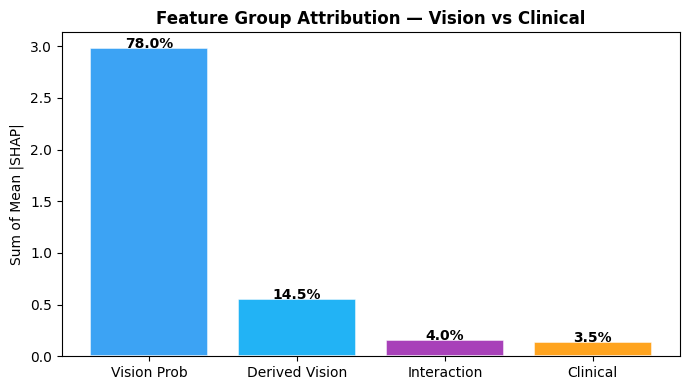

  💾 Saved → /kaggle/working/shap_group_attribution.png

✅ Cell 10 complete.


In [11]:
print("\n" + "=" * 65)
print("CELL 10 — SHAP INTERPRETABILITY")
print("=" * 65)
 
feature_names = ALL_FEATURE_COLS
explainer     = shap.TreeExplainer(final_model)
shap_values   = explainer.shap_values(X)
# shap_values is a list of 5 arrays, each (N, n_features)
 
# ── 10a. Mean |SHAP| global importance ───────────────────────────────────────
if isinstance(shap_values, list):
    mean_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    mean_abs = np.abs(shap_values).mean(axis=(0, -1)) if shap_values.ndim == 3 \
               else np.abs(shap_values).mean(axis=0)
 
GROUP_MAP = {}
for c in feature_names:
    if c in VISION_PROB_COLS:         GROUP_MAP[c] = "Vision Prob"
    elif c in DERIVED_VISION_COLS:    GROUP_MAP[c] = "Derived Vision"
    elif c in INTERACTION_COLS:       GROUP_MAP[c] = "Interaction"
    else:                             GROUP_MAP[c] = "Clinical"
 
shap_df = pd.DataFrame({
    "Feature"     : feature_names,
    "Mean |SHAP|" : mean_abs,
    "Group"       : [GROUP_MAP[c] for c in feature_names],
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)
 
print("\n  Top 15 features (global):")
print(shap_df.head(15).to_string(index=False))
 
GROUP_COLORS = {
    "Vision Prob"    : "#2196F3",
    "Derived Vision" : "#03A9F4",
    "Clinical"       : "#FF9800",
    "Interaction"    : "#9C27B0",
}
 
# ── 10b. Global bar chart ─────────────────────────────────────────────────────
top_n    = 20
top_shap = shap_df.head(top_n)
bar_cols = [GROUP_COLORS[g] for g in top_shap["Group"]]
 
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_shap["Feature"][::-1], top_shap["Mean |SHAP|"][::-1],
        color=bar_cols[::-1], alpha=0.90, edgecolor="white")
ax.set_xlabel("Mean |SHAP| Value", fontsize=11)
ax.set_title(f"Top {top_n} Features — Fusion Model (All Grades)", fontweight="bold")
legend_elems = [mpatches.Patch(facecolor=v, label=k)
                for k, v in GROUP_COLORS.items()
                if k in top_shap["Group"].values]
ax.legend(handles=legend_elems, loc="lower right", fontsize=9)
plt.tight_layout()
shap_global = os.path.join(FusionConfig.OUTPUT_DIR, "shap_global_importance.png")
plt.savefig(shap_global, dpi=150, bbox_inches="tight")
plt.show()
print(f"  💾 Saved → {shap_global}")
 
# ── 10c. Beeswarm per grade ───────────────────────────────────────────────────
sv_list = shap_values if isinstance(shap_values, list) else [
    shap_values[:, :, i] for i in range(5)
]
grade_subtitles = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
 
for g_idx, subtitle in enumerate(grade_subtitles):
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_list[g_idx], features=X, feature_names=feature_names,
                      show=False, max_display=15, plot_type="dot")
    plt.title(f"SHAP Beeswarm — Grade {g_idx} ({subtitle})", fontweight="bold")
    plt.tight_layout()
    bee_path = os.path.join(FusionConfig.OUTPUT_DIR, f"shap_beeswarm_grade{g_idx}.png")
    plt.savefig(bee_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  💾 Saved → {bee_path}")
 
# ── 10d. Group attribution bar ────────────────────────────────────────────────
group_totals = shap_df.groupby("Group")["Mean |SHAP|"].sum().sort_values(ascending=False)
total_shap   = group_totals.sum()
 
print(f"\n  FEATURE GROUP ATTRIBUTION")
for grp, val in group_totals.items():
    pct = val / total_shap * 100
    bar = "█" * int(pct / 2)
    print(f"  {grp:<20}: {val:.4f}  ({pct:5.1f}%)  {bar}")
 
fig, ax = plt.subplots(figsize=(7, 4))
cols = [GROUP_COLORS.get(g, "#888") for g in group_totals.index]
bars = ax.bar(group_totals.index, group_totals.values,
              color=cols, alpha=0.88, edgecolor="white", linewidth=1.2)
ax.set_ylabel("Sum of Mean |SHAP|")
ax.set_title("Feature Group Attribution — Vision vs Clinical", fontweight="bold")
for bar, val in zip(bars, group_totals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f"{val/total_shap*100:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
attr_path = os.path.join(FusionConfig.OUTPUT_DIR, "shap_group_attribution.png")
plt.savefig(attr_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  💾 Saved → {attr_path}")
print("\n✅ Cell 10 complete.")
 

# CELL 11 — CROSS-DATASET GENERALISATION AUDIT


CELL 11 — CROSS-DATASET GENERALISATION AUDIT
  Vision argmax QWK   : 0.9234
  Fusion model QWK    : 0.9221
  Δ QWK (improvement) : -0.0012

  Per-grade accuracy (vision only vs fusion):
  Grade         N     Vision     Fusion        Δ
  ──────────────────────────────────────────────
  Grade 0   55162      0.9726      0.9713   -0.0013
  Grade 1   18470      0.7783      0.7779   -0.0005
  Grade 2   24198      0.7861      0.7832   -0.0029
  Grade 3    7936      0.9585      0.9554   -0.0032
  Grade 4    9475      0.9408      0.9370   -0.0038


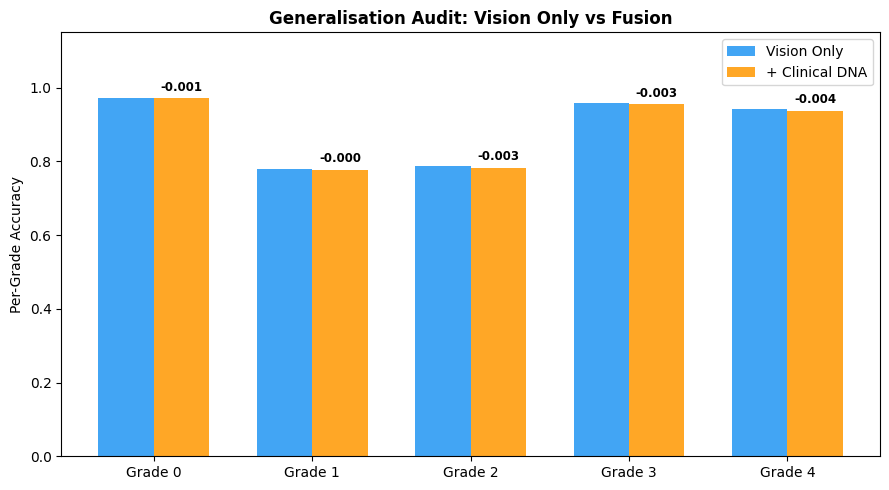

  💾 Saved → /kaggle/working/fusion_generalisation_audit.png

✅ Cell 11 complete.


In [12]:
print("\n" + "=" * 65)
print("CELL 11 — CROSS-DATASET GENERALISATION AUDIT")
print("=" * 65)
 
vision_only_preds = df["f_vision_argmax"].astype(int).values
vision_qwk        = cohen_kappa_score(y, vision_only_preds, weights="quadratic")
delta_qwk         = mean_kappa - vision_qwk
 
print(f"  Vision argmax QWK   : {vision_qwk:.4f}")
print(f"  Fusion model QWK    : {mean_kappa:.4f}")
print(f"  Δ QWK (improvement) : {delta_qwk:+.4f}")
 
print(f"\n  Per-grade accuracy (vision only vs fusion):")
print(f"  {'Grade':<8} {'N':>6} {'Vision':>10} {'Fusion':>10} {'Δ':>8}")
print(f"  {'─'*46}")
 
v_accs, f_accs = [], []
for g in range(5):
    mask  = y == g
    n     = mask.sum()
    v_acc = accuracy_score(y[mask], vision_only_preds[mask]) if n else 0.0
    f_acc = accuracy_score(y[mask], oof_preds[mask]) if n else 0.0
    v_accs.append(v_acc); f_accs.append(f_acc)
    delta = f_acc - v_acc
    print(f"  Grade {g}  {n:>6}  {v_acc:>10.4f}  {f_acc:>10.4f}  {delta:>+8.4f}")
 
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(5);  w = 0.35
ax.bar(x_pos - w/2, v_accs, w, label="Vision Only", color="#2196F3", alpha=0.85)
ax.bar(x_pos + w/2, f_accs, w, label="+ Clinical DNA", color="#FF9800", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Grade {g}" for g in range(5)])
ax.set_ylabel("Per-Grade Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Generalisation Audit: Vision Only vs Fusion", fontweight="bold")
ax.legend()
for i, (v, f) in enumerate(zip(v_accs, f_accs)):
    delta = f - v
    ax.text(i + w/2, f + 0.02, f"{delta:+.3f}",
            ha="center", fontsize=8.5, fontweight="bold")
plt.tight_layout()
gen_path = os.path.join(FusionConfig.OUTPUT_DIR, "fusion_generalisation_audit.png")
plt.savefig(gen_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  💾 Saved → {gen_path}")
print("\n✅ Cell 11 complete.")

# Cell 12: Final

In [13]:
import json
import os

print("\n" + "=" * 65)
print("CELL 12 — FINAL RESEARCH SUMMARY")
print("=" * 65)

# ── 12a. Calculate Delta QWK ────────────────────────────────────────────────
# We compare the Fusion QWK to the original Vision-only argmax QWK
vision_only_preds = df["f_vision_argmax"].astype(int).values
vision_qwk = cohen_kappa_score(y, vision_only_preds, weights="quadratic")
delta_qwk = mean_kappa - vision_qwk

# ── 12b. Build Summary Dictionary ───────────────────────────────────────────
summary = {
    "model"            : "Level 2 XGBoost Fusion (Vision Ensemble + Clinical DNA)",
    "dataset"          : f"Unified Vision + IDRiD Bridge ({len(df):,} images)",
    "bridge_key"       : VISION_TARGET, # Replaced MERGE_KEY
    "n_features"       : int(X.shape[1]),
    "feature_breakdown": {
        "vision_prob"    : len(VISION_PROB_COLS),
        "derived_vision" : len(DERIVED_VISION_COLS),
        "clinical"       : len(BRIDGED_CLINICAL_COLS),
        "interaction"    : len(INTERACTION_COLS),
    },
    "cv"                        : f"{FusionConfig.N_FOLDS}-Fold Stratified",
    "oof_qwk_mean"              : round(mean_kappa, 4),
    "oof_qwk_std"               : round(std_kappa, 4),
    "oof_accuracy"              : round(float(overall_acc), 4),
    "vision_only_qwk"           : round(float(vision_qwk), 4),
    "delta_qwk_vs_vision_only"  : round(float(delta_qwk), 4),
    "top_5_features"            : shap_df["Feature"].head(5).tolist(),
    "feature_group_attribution" : {
        grp: f"{val/total_shap*100:.1f}%"
        for grp, val in group_totals.items()
    },
    "fold_kappas"     : [round(k, 4) for k in fold_kappas],
    "saved_artefacts" : [
        "fusion_model_final.json",
        "fusion_scaler.pkl",
        "oof_predictions_fusion.csv",
        "fusion_results_table.tex",
        "fusion_confusion_matrix.png",
        "fusion_per_grade_metrics.png",
        "shap_global_importance.png",
        "shap_beeswarm_grade0.png",
        "shap_beeswarm_grade1.png",
        "shap_beeswarm_grade2.png",
        "shap_beeswarm_grade3.png",
        "shap_beeswarm_grade4.png",
        "shap_group_attribution.png",
        "fusion_summary.json",
    ],
}

# ── 12c. Export to JSON ──────────────────────────────────────────────────────
summary_path = os.path.join(FusionConfig.OUTPUT_DIR, "fusion_summary.json")
with open(summary_path, "w") as fh:
    json.dump(summary, fh, indent=2)

print(json.dumps(summary, indent=2))
print(f"\n  💾 Summary Saved → {summary_path}")
print(f"  🏁 All artefacts in: {os.path.abspath(FusionConfig.OUTPUT_DIR)}")
print("\n✅ PHASE 3 COMPLETE.")


CELL 12 — FINAL RESEARCH SUMMARY
{
  "model": "Level 2 XGBoost Fusion (Vision Ensemble + Clinical DNA)",
  "dataset": "Unified Vision + IDRiD Bridge (115,241 images)",
  "bridge_key": "label",
  "n_features": 80,
  "feature_breakdown": {
    "vision_prob": 5,
    "derived_vision": 6,
    "clinical": 66,
    "interaction": 3
  },
  "cv": "5-Fold Stratified",
  "oof_qwk_mean": 0.9221,
  "oof_qwk_std": 0.0027,
  "oof_accuracy": 0.8969,
  "vision_only_qwk": 0.9234,
  "delta_qwk_vs_vision_only": -0.0012,
  "top_5_features": [
    "vision_ens_prob_3",
    "vision_ens_prob_4",
    "vision_ens_prob_0",
    "vision_ens_prob_1",
    "vision_ens_prob_2"
  ],
  "feature_group_attribution": {
    "Vision Prob": "78.0%",
    "Derived Vision": "14.5%",
    "Interaction": "4.0%",
    "Clinical": "3.5%"
  },
  "fold_kappas": [
    0.9254,
    0.9248,
    0.9182,
    0.9207,
    0.9215
  ],
  "saved_artefacts": [
    "fusion_model_final.json",
    "fusion_scaler.pkl",
    "oof_predictions_fusion.csv",
